In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

batch1 = '/content/drive/MyDrive/Colab Notebooks/chicago_batch_1.csv'
batch2 = '/content/drive/MyDrive/Colab Notebooks/chicago_batch_2.csv'
batch3 = '/content/drive/MyDrive/Colab Notebooks/chicago_batch_3.csv'
batch4 = '/content/drive/MyDrive/Colab Notebooks/chicago_batch_4.csv'
batch5 = '/content/drive/MyDrive/Colab Notebooks/chicago_batch_5.csv'
batch6 = '/content/drive/MyDrive/Colab Notebooks/chicago_batch_6.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data2026 = pd.read_csv(batch1)
data2025 = pd.read_csv(batch2)
data2024 = pd.read_csv(batch3)
data2023 = pd.read_csv(batch4)
data2022 = pd.read_csv(batch5)
data2021 = pd.read_csv(batch6)

In [5]:
mass_ds = pd.concat([data2021, data2022, data2023, data2024, data2025, data2026], ignore_index=True)
mass_ds.head()

,crash_record_id,crash_date,posted_speed_limit,traffic_control_device,device_condition,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,...,hit_and_run_i,crash_date_est_i,private_property_i,statements_taken_i,work_zone_i,photos_taken_i,work_zone_type,dooring_i,workers_present_i,lane_cnt
0,7ae9fb85c2ccbd48dc7b493095507641d821f6a9c3222c...,2021-09-13T19:10:00.000,30,STOP SIGN/FLASHER,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",ANGLE,NOT DIVIDED,STRAIGHT AND LEVEL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,46a733b3e52979358689abe85dcb49e1bb7c9667026884...,2021-09-13T19:01:00.000,35,NO CONTROLS,NO CONTROLS,CLEAR,DAWN,TURNING,FOUR WAY,STRAIGHT AND LEVEL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,686c18450f0f4132029e8512f0d6b8d0c3e8663b455381...,2021-09-13T19:00:00.000,30,NO CONTROLS,NO CONTROLS,CLEAR,DARKNESS,PARKED MOTOR VEHICLE,PARKING LOT,STRAIGHT AND LEVEL,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,d1e90dcb60624c5a53427bff0698a97e39a37c4a23533a...,2021-09-13T18:58:00.000,20,OTHER WARNING SIGN,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,ONE-WAY,STRAIGHT AND LEVEL,...,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5a283cf421d6db29dbab543e785446da0bdd7c6bab6a44...,2021-09-13T18:57:00.000,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT AND LEVEL,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:

print(mass_ds.shape)

(600000, 49)


In [7]:
mass_ds.columns

Index(['crash_record_id', 'crash_date', 'posted_speed_limit',
       'traffic_control_device', 'device_condition', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'report_type',
       'crash_type', 'intersection_related_i', 'damage',
       'date_police_notified', 'prim_contributory_cause',
       'sec_contributory_cause', 'street_no', 'street_direction',
       'street_name', 'beat_of_occurrence', 'num_units', 'most_severe_injury',
       'injuries_total', 'injuries_fatal', 'injuries_incapacitating',
       'injuries_non_incapacitating', 'injuries_reported_not_evident',
       'injuries_no_indication', 'injuries_unknown', 'crash_hour',
       'crash_day_of_week', 'crash_month', 'latitude', 'longitude', 'location',
       ':@computed_region_rpca_8um6', 'hit_and_run_i', 'crash_date_est_i',
       'private_property_i', 'statements_taken_i', 'work_zone_i',
       'photos_taken_i', 'work_zo

In [8]:
mass_ds.isnull().sum()

,0
crash_record_id,0
crash_date,0
posted_speed_limit,0
traffic_control_device,0
device_condition,0
weather_condition,0
lighting_condition,0
first_crash_type,0
trafficway_type,0
alignment,0


In [9]:
cols_to_drop = [
    'work_zone_type', 'workers_present_i', 'lane_cnt',
    'dooring_i', 'work_zone_i', 'photos_taken_i',
    'statements_taken_i', 'private_property_i',
    'crash_date_est_i'
]

In [10]:
df = mass_ds.copy()

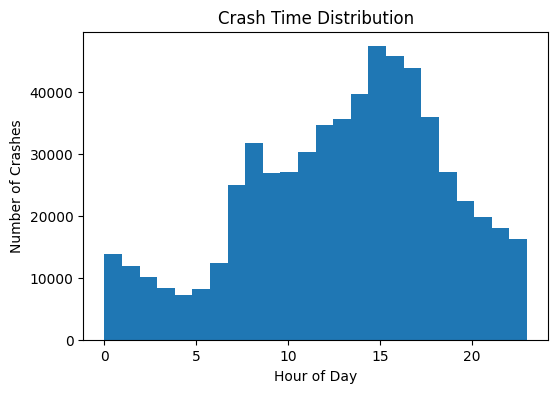

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['crash_hour'], bins=24)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crashes")
plt.title("Crash Time Distribution")

plt.show()

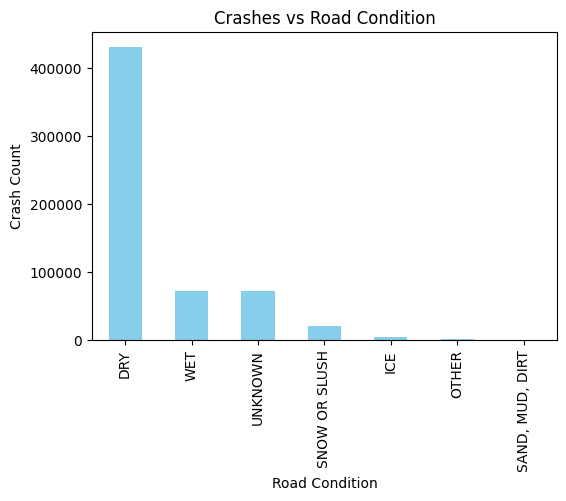

In [16]:
import matplotlib.pyplot as plt

colors = ['red' if x == 0 else 'skyblue' for x in df['roadway_surface_cond'].value_counts().index]

df['roadway_surface_cond'].value_counts().plot(
    kind='bar',
    color=colors,
    figsize=(6,4)
)

plt.xlabel("Road Condition")
plt.ylabel("Crash Count")
plt.title("Crashes vs Road Condition")

plt.show()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [18]:
df = df.dropna(subset=['latitude','longitude'])

In [19]:
# Keep only valid Chicago region
df = df[
    (df['latitude'] > 41.5) & (df['latitude'] < 42.1) &
    (df['longitude'] > -88) & (df['longitude'] < -87.5)
]

In [20]:
location_df = df.groupby(['latitude','longitude']).size().reset_index(name='accident_count')

In [21]:
features = df.groupby(['latitude','longitude']).agg({
    'posted_speed_limit':'mean',
    'num_units':'mean',
    'crash_hour':'mean'
}).reset_index()

final_df = location_df.merge(features, on=['latitude','longitude'])

In [22]:
X = final_df[['latitude','longitude','posted_speed_limit','num_units','crash_hour']]
y = final_df['accident_count']


In [23]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

In [24]:
model_reg = RandomForestRegressor(n_estimators=80, random_state=42)
model_reg.fit(X_train, y_train)

RandomForestRegressor(n_estimators=80, random_state=42)

In [25]:
y_pred = model_reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.5949252201793903
RMSE: 3.1758131660643065
R2: 0.6875763167359854


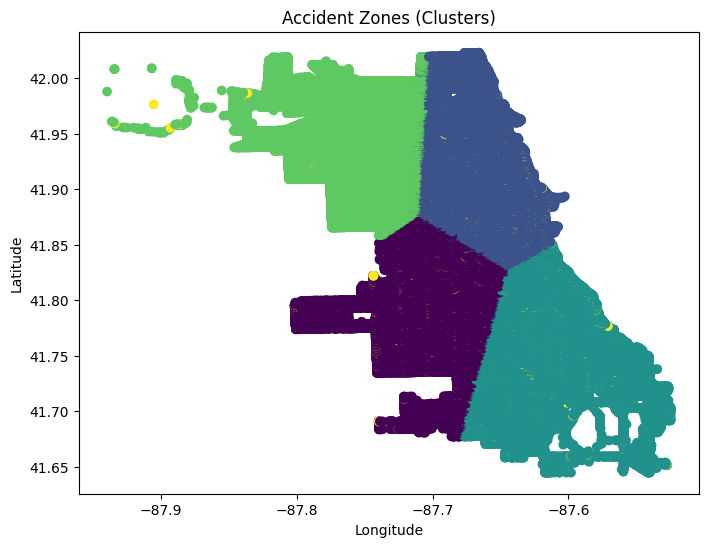

In [26]:
scaler = StandardScaler()
cluster_data = scaler.fit_transform(final_df[['latitude','longitude','accident_count']])

kmeans = KMeans(n_clusters=5, random_state=42)
final_df['cluster'] = kmeans.fit_predict(cluster_data)


plt.figure(figsize=(8,6))
plt.scatter(final_df['longitude'], final_df['latitude'], c=final_df['cluster'])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident Zones (Clusters)")
plt.show()#Each color = one cluster (zone) ,Each dot = one location (latitude, longitude)

In [27]:
final_df.groupby('cluster')['accident_count'].mean()

,accident_count
cluster,
0,1.962571
1,2.296422
2,1.948773
3,1.973150
4,48.229941


In [28]:
final_df['cluster'].value_counts() #num of locations

,count
cluster,
1,74910
3,62755
2,56103
0,50763
4,1857


Dangerous crash (1)
Not dangerous (0)


In [29]:
#create target
df['location_id'] = (
    df['latitude'].round(3).astype(str) + "_" +
    df['longitude'].round(3).astype(str)
)

df['accident_count'] = df.groupby('location_id')['crash_record_id'].transform('count')

threshold = df['accident_count'].quantile(0.75)
df['risk_label'] = (df['accident_count'] > threshold).astype(int)

In [30]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

cat_cols = [
    'traffic_control_device',
    'device_condition',
    'weather_condition',
    'lighting_condition',
    'first_crash_type',
    'trafficway_type',
    'alignment',
    'roadway_surface_cond',
    'road_defect',
    'crash_type',
    'prim_contributory_cause',
    'sec_contributory_cause'
]

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [31]:
df_encoded['is_night'] = df_encoded['crash_hour'].apply(
    lambda x: 1 if (x >= 18 or x <= 6) else 0
)
df_encoded['is_weekend'] = df_encoded['crash_day_of_week'].apply(
    lambda x: 1 if x in [6, 7] else 0   # Saturday, Sunday
)

In [32]:
features = [
    'posted_speed_limit',
    'traffic_control_device',
    'device_condition',
    'weather_condition',
    'lighting_condition',
    'first_crash_type',
    'trafficway_type',
    'alignment',
    'roadway_surface_cond',
    'road_defect',
    'crash_type',
    'prim_contributory_cause',
    'sec_contributory_cause',
    'num_units',
    'crash_hour',
    'crash_day_of_week',
    'crash_month',
    'latitude',
    'longitude',
    'is_night',
    'is_weekend'
]

X = df_encoded[features]
y = df_encoded['risk_label']

In [33]:
from imblearn.over_sampling import SMOTE

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [36]:
print(y_train.value_counts())
print(y_train_res.value_counts())

risk_label
0    356895
1    118601
Name: count, dtype: int64
risk_label
0    356895
1    356895
Name: count, dtype: int64


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.ensemble import RandomForestClassifier

model_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')


In [39]:
model_clf.fit(X_train_res, y_train_res)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = model_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9508895899053628
[[85999  3568]
 [ 2270 27038]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     89567
           1       0.88      0.92      0.90     29308

    accuracy                           0.95    118875
   macro avg       0.93      0.94      0.93    118875
weighted avg       0.95      0.95      0.95    118875




Accuracy 95%	Overall strong model
Recall 0.92 (Class 1)	Catches most risk cases
Precision 0.88	Few wrong alarms
F1 0.90	Balanced performance

Recall-Type1 Error(FALSE NEGATIVE)

In [41]:
def risk_action(x):
    return "RISK - Dispatch Emergency Services" if x == 1 else "SAFE - Normal Handling"

# STEP 1: predictions (IMPORTANT)
y_prob = model_clf.predict_proba(X_test)[:, 1]
y_pred_final = (y_prob >= 0.3).astype(int)

# STEP 2: results table
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_final
})

# STEP 3: action column
results["Action"] = results["Predicted"].apply(risk_action)

print(results.head())

   Actual  Predicted                              Action
0       0          0              SAFE - Normal Handling
1       0          0              SAFE - Normal Handling
2       0          0              SAFE - Normal Handling
3       0          0              SAFE - Normal Handling
4       0          1  RISK - Dispatch Emergency Services


<Axes: >

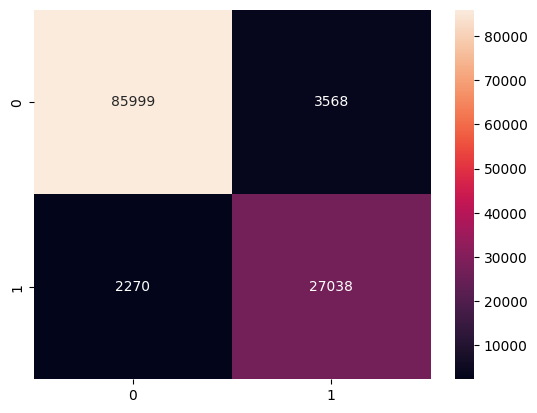

In [42]:

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

In [43]:
from google.colab import drive
drive.mount('/content/drive')

comments = '/content/drive/MyDrive/Colab Notebooks/youtube_bigdata.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
import pandas as pd
import numpy as np
import re #text pattern cleaning

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer# converts words to base form

from textblob import TextBlob#sentiment analysis
from sklearn.feature_extraction.text import TfidfVectorizer#text to numbers
from sklearn.decomposition import TruncatedSVD

In [45]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [46]:
import pandas as pd

df = pd.read_csv(comments)

print(df.head())
print(df.info())

      video_id                                            comment
0  PFHBRUj6fhM  These numb and dumb jackass clowns drive on th...
1  PFHBRUj6fhM  Gang stuff again,  fatigue.. refused treatment...
2  PFHBRUj6fhM             "The hoodrat 500" surprise, surprise!🤣
3  PFHBRUj6fhM  People need to stop driving so damn fast 55 mi...
4  PFHBRUj6fhM  Nobody is talking about the way cars are conti...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7795 entries, 0 to 7794
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   video_id  7795 non-null   object
 1   comment   7795 non-null   object
dtypes: object(2)
memory usage: 121.9+ KB
None


In [47]:
df = df[['video_id', 'comment']].dropna()

print(df.head())

      video_id                                            comment
0  PFHBRUj6fhM  These numb and dumb jackass clowns drive on th...
1  PFHBRUj6fhM  Gang stuff again,  fatigue.. refused treatment...
2  PFHBRUj6fhM             "The hoodrat 500" surprise, surprise!🤣
3  PFHBRUj6fhM  People need to stop driving so damn fast 55 mi...
4  PFHBRUj6fhM  Nobody is talking about the way cars are conti...


In [48]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()

    # remove emojis / unicode
    text = text.encode('ascii', 'ignore').decode('ascii')

    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)

df['clean_comment'] = df['comment'].apply(clean_text)

In [49]:
def sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment_score'] = df['comment'].apply(sentiment)

print(df[['comment', 'sentiment_score']].head())

                                             comment  sentiment_score
0  These numb and dumb jackass clowns drive on th...        -0.243750
1  Gang stuff again,  fatigue.. refused treatment...         0.000000
2             "The hoodrat 500" surprise, surprise!🤣         0.000000
3  People need to stop driving so damn fast 55 mi...         0.291188
4  Nobody is talking about the way cars are conti...        -0.200000


In [50]:
def sentiment_class(x):
    if x > 0.05:
        return 1
    elif x < -0.05:
        return -1
    else:
        return 0

df['sentiment_label'] = df['sentiment_score'].apply(sentiment_class)

print(df[['comment', 'sentiment_score', 'sentiment_label']].head())

                                             comment  sentiment_score  \
0  These numb and dumb jackass clowns drive on th...        -0.243750   
1  Gang stuff again,  fatigue.. refused treatment...         0.000000   
2             "The hoodrat 500" surprise, surprise!🤣         0.000000   
3  People need to stop driving so damn fast 55 mi...         0.291188   
4  Nobody is talking about the way cars are conti...        -0.200000   

   sentiment_label  
0               -1  
1                0  
2                0  
3                1  
4               -1  


In [51]:
complaint_words = [
    "accident", "crash", "danger", "fast", "speed",
    "traffic", "jam", "bad", "unsafe", "hurt",
    "road", "signal", "reckless"
]

def complaint_score(text):
    text = text.lower()
    return sum(1 for w in complaint_words if w in text)

df['complaint_score'] = df['clean_comment'].apply(complaint_score)

print(df[['comment', 'complaint_score']].head())

                                             comment  complaint_score
0  These numb and dumb jackass clowns drive on th...                1
1  Gang stuff again,  fatigue.. refused treatment...                0
2             "The hoodrat 500" surprise, surprise!🤣                0
3  People need to stop driving so damn fast 55 mi...                2
4  Nobody is talking about the way cars are conti...                1


In [52]:
tfidf = TfidfVectorizer(max_features=1000)

tfidf_matrix = tfidf.fit_transform(df['clean_comment'])

In [53]:
svd = TruncatedSVD(n_components=2, random_state=42)

svd_result = svd.fit_transform(tfidf_matrix)

df['svd_1'] = svd_result[:, 0]
df['svd_2'] = svd_result[:, 1]

print(df[['svd_1', 'svd_2']].head())

      svd_1     svd_2
0  0.056846 -0.023624
1  0.016183  0.001198
2  0.000000  0.000000
3  0.203764 -0.045489
4  0.148114 -0.076980


In [54]:
final_df = df[[
    'video_id',
    'sentiment_score',
    'complaint_score',
    'svd_1',
    'svd_2'
]]

print(final_df.head())

      video_id  sentiment_score  complaint_score     svd_1     svd_2
0  PFHBRUj6fhM        -0.243750                1  0.056846 -0.023624
1  PFHBRUj6fhM         0.000000                0  0.016183  0.001198
2  PFHBRUj6fhM         0.000000                0  0.000000  0.000000
3  PFHBRUj6fhM         0.291188                2  0.203764 -0.045489
4  PFHBRUj6fhM        -0.200000                1  0.148114 -0.076980


In [55]:
df['severity_score'] = (
    df['complaint_score'] * 2 +
    (-df['sentiment_score'])
)

print(df[['comment', 'severity_score']].head())

                                             comment  severity_score
0  These numb and dumb jackass clowns drive on th...        2.243750
1  Gang stuff again,  fatigue.. refused treatment...        0.000000
2             "The hoodrat 500" surprise, surprise!🤣        0.000000
3  People need to stop driving so damn fast 55 mi...        3.708812
4  Nobody is talking about the way cars are conti...        2.200000


In [ ]:
import joblib
from google.colab import drive
drive.mount('/content/drive')

joblib.dump({
    "model_clf": model_clf,
    "model_reg": model_reg,
    "features": list(X.columns),
    "threshold": 0.3
}, "/content/drive/MyDrive/Colab Notebooks/chicago_model_v1.pkl")

print("Saved successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/Colab Notebooks/chicago_model_v1.pkl"))

True


In [ ]:
import joblib

data = joblib.load("/content/drive/MyDrive/Colab Notebooks/chicago_model_v1.pkl")

print(data.keys())

dict_keys(['model_clf', 'model_reg', 'features', 'threshold'])


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/Colab Notebooks/chicago_model_v1.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>